# Rollout Visualisation — Video + Joint Angles + Torques + Velocities

Downloads the video and matching CSV from a W&B run, then shows:
1. **Video** of the rollout
2. **Manipulator joint angles** (wrapped to [−π, +π])
3. **Finger / gripper positions** (separate graph)
4. **All velocities** overlaid
5. **All torques** overlaid

In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, json
from IPython.display import Video, display, HTML

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1 — Configuration

In [2]:
# ──────────── EDIT THESE ────────────
ENTITY  = "weissma6-zhaw-school-of-engineering"
PROJECT = "UR10_pick_ppo"


# Leave None to auto-select the most recent finished run
RUN_ID  = "DomainR_off_forcerange10_20260206_173852_9143"
# ────────────────────────────────────
'''
Ineresting examples: 
"DomainR_MFR_lr0.0006_512_20260206_161524_7373" - drops the box successfully after pick
"" -

'''

SAVE_DIR = "run_graphs/"
RUN_DIR = os.path.join(SAVE_DIR, RUN_ID)
os.makedirs(RUN_DIR, exist_ok=True)
print(f"Saving to {RUN_DIR}")

Saving to run_graphs/DomainR_off_forcerange10_20260206_173852_9143


## 2 — Fetch run & files

In [3]:
api = wandb.Api()

if RUN_ID:
    run = api.run(f'{ENTITY}/{PROJECT}/{RUN_ID}')
else:
    runs = api.runs(f'{ENTITY}/{PROJECT}', filters={'state': 'finished'},
                    order='-created_at', per_page=1)
    run = runs[0]

print(f'Run: {run.name}  ({run.id})')
print(f'State: {run.state}  |  Runtime: {run.summary.get("_runtime", 0)/60:.1f} min')

run_files = list(run.files())
print(f'\nFiles ({len(run_files)}):')
for f in run_files:
    print(f'  {f.name}  ({f.size:,} bytes)')

wandb: Currently logged in as: weissma6 (weissma6-zhaw-school-of-engineering) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Run: DomainR_off_forcerange10_20260206_173852_9143  (DomainR_off_forcerange10_20260206_173852_9143)
State: finished  |  Runtime: 35.1 min

Files (27):
  artifact/2445996716/wandb_manifest.json  (351 bytes)
  artifact/2446036612/wandb_manifest.json  (351 bytes)
  artifact/2446070224/wandb_manifest.json  (351 bytes)
  artifact/2446081793/wandb_manifest.json  (351 bytes)
  artifact/2446082039/wandb_manifest.json  (563 bytes)
  artifact/2446104672/wandb_manifest.json  (0 bytes)
  config.yaml  (4,466 bytes)
  media/table/eval/rollout_data_13107200_4b030aaf58acb6d5fd83.table.json  (246,192 bytes)
  media/table/eval/rollout_data_29491200_0282ddcfc97e645fa2c0.table.json  (247,079 bytes)
  media/table/eval/rollout_data_42598400_ceab5d02d9dcc3efbad5.table.json  (246,576 bytes)
  media/table/eval/rollout_data_45875200_284ae46c16cdb17d9f76.table.json  (246,477 bytes)
  media/videos/eval/video_26214400_d8c9413fe6bc67abb210.mp4  (567,471 bytes)
  media/videos/eval/video_39321600_ab01bc95525fdb622b36

In [4]:
import re

os.makedirs('dl', exist_ok=True)

def _extract_steps(f):
    m = re.search(r'steps(\d+)', f.name)
    return int(m.group(1)) if m else 0

# Only use the UR10PickCube files (not the media/videos duplicates)
named_videos = [f for f in run_files if f.name.endswith('.mp4') and 'UR10PickCube' in f.name]
named_csvs   = [f for f in run_files if f.name.endswith('.csv') and 'UR10PickCube' in f.name]

# Sort by step count
named_videos.sort(key=_extract_steps)
named_csvs.sort(key=_extract_steps)

print('Available video/csv pairs:')
for v in named_videos:
    steps = _extract_steps(v)
    has_csv = any(_extract_steps(c) == steps for c in named_csvs)
    print(f'  steps={steps:>12,}  csv={"✓" if has_csv else "✗"}  {os.path.basename(v.name)}')

# Pick the highest-step pair
vf = named_videos[-1]
vf_steps = _extract_steps(vf)
cf = [c for c in named_csvs if _extract_steps(c) == vf_steps][0]

# Download and flatten into dl/
vf.download(root='dl', replace=True)
cf.download(root='dl', replace=True)
video_path = os.path.join('dl', vf.name)
csv_path   = os.path.join('dl', cf.name)

print(f'\nSelected video: {os.path.basename(vf.name)}')
print(f'Selected CSV:   {os.path.basename(cf.name)}')
rew_match = re.search(r"rew([\d.]+)", vf.name)
rew_str = rew_match.group(1) if rew_match else "?"
print(f'Steps: {vf_steps:,}  |  Reward: {rew_str}')

df = pd.read_csv(csv_path)
print(f'\nLoaded {len(df)} rows × {len(df.columns)} columns')
display(df.head(3))


Available video/csv pairs:
  steps=  13,107,200  csv=✓  UR10PickCube_DomainR_off_forcerange10_rew1517.4_steps13107200.mp4
  steps=  29,491,200  csv=✓  UR10PickCube_DomainR_off_forcerange10_rew1570.0_steps29491200.mp4
  steps=  42,598,400  csv=✓  UR10PickCube_DomainR_off_forcerange10_rew1565.5_steps42598400.mp4
  steps=  45,875,200  csv=✓  UR10PickCube_DomainR_off_forcerange10_rew1568.5_steps45875200.mp4

Selected video: UR10PickCube_DomainR_off_forcerange10_rew1568.5_steps45875200.mp4
Selected CSV:   UR10PickCube_DomainR_off_forcerange10_rew1568.5_steps45875200.csv
Steps: 45,875,200  |  Reward: 1568.5

Loaded 151 rows × 87 columns


,timestep,reward,ctrl_0,ctrl_1,ctrl_2,ctrl_3,ctrl_4,ctrl_5,ctrl_6,world_x,...,qpos_joint_5,qpos_joint_6,qpos_joint_7,qpos_joint_8,qpos_joint_9,qpos_joint_10,qpos_joint_11,qpos_joint_12,qpos_joint_13,qpos_joint_14
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,-1.468541,0.007511,0.007702,0.51849,0.090396,0.030000,1.0,0.000000e+00,0.000000e+00,0.000000e+00
1,1,1.102811,-0.634607,0.977649,0.804770,-0.834482,0.021081,-0.463381,-0.593861,0.0,...,-1.471624,0.004019,-0.000250,0.51849,0.090396,0.029887,1.0,6.996105e-10,-4.057744e-09,2.592059e-08
2,2,1.161416,-0.737702,0.976816,0.890693,-0.909969,-0.323397,-0.534405,-0.619200,0.0,...,-1.478003,-0.000171,-0.005500,0.51849,0.090396,0.029949,1.0,-4.477525e-09,-5.596846e-10,2.250998e-08


## 3 — Detect data channels

In [5]:
cols = list(df.columns)


def _num_sort_key(col):
    """Sort by trailing number so joint_2 comes before joint_10."""
    m = re.search(r'(\d+)$', col)
    return (0, int(m.group(1))) if m else (1, col)

qpos_cols   = sorted([c for c in cols if c.startswith('qpos_')],   key=_num_sort_key)
vel_cols    = sorted([c for c in cols if c.startswith('vel_')],     key=_num_sort_key)
torque_cols = sorted([c for c in cols if c.startswith('torque_')],  key=_num_sort_key)
ctrl_cols   = sorted([c for c in cols if c.startswith('ctrl_')],    key=_num_sort_key)

print(f'qpos   columns ({len(qpos_cols)}): {qpos_cols}')
print(f'vel    columns ({len(vel_cols)}): {vel_cols}')
print(f'torque columns ({len(torque_cols)}): {torque_cols}')
print(f'ctrl   columns ({len(ctrl_cols)}): {ctrl_cols}')

# Quick sanity check: qpos_joint_8 should be box_x ≈ 0.7
print(f'\nSanity: qpos_cols[8] = {qpos_cols[8]}, first value = {df[qpos_cols[8]].iloc[0]:.4f}  (expect ~0.7)')

# Build readable name lookups
qpos_names   = [c.replace('qpos_', '')   for c in qpos_cols]
vel_names    = [c.replace('vel_', '')     for c in vel_cols]
torque_names = [c.replace('torque_', '')  for c in torque_cols]
ctrl_names   = [c.replace('ctrl_', '')    for c in ctrl_cols]


qpos   columns (15): ['qpos_joint_0', 'qpos_joint_1', 'qpos_joint_2', 'qpos_joint_3', 'qpos_joint_4', 'qpos_joint_5', 'qpos_joint_6', 'qpos_joint_7', 'qpos_joint_8', 'qpos_joint_9', 'qpos_joint_10', 'qpos_joint_11', 'qpos_joint_12', 'qpos_joint_13', 'qpos_joint_14']
vel    columns (14): ['vel_0', 'vel_1', 'vel_2', 'vel_3', 'vel_4', 'vel_5', 'vel_6', 'vel_7', 'vel_8', 'vel_9', 'vel_10', 'vel_11', 'vel_12', 'vel_13']
torque columns (7): ['torque_wrist_1', 'torque_wrist_2', 'torque_wrist_3', 'torque_elbow', 'torque_hande_fingers_actuator', 'torque_shoulder_lift', 'torque_shoulder_pan']
ctrl   columns (7): ['ctrl_0', 'ctrl_1', 'ctrl_2', 'ctrl_3', 'ctrl_4', 'ctrl_5', 'ctrl_6']

Sanity: qpos_cols[8] = qpos_joint_8, first value = 0.5185  (expect ~0.7)


## 4 — Classify qpos: arm / fingers / box

UR10 qpos layout from XML keyframe:  
`qpos = [arm×6] [finger×2] [box_xyz×3] [box_quat×4]`  
`ctrl  = [arm×6] [gripper×1]`

In [6]:
# ══════════════════════════════════════════════
# UR10 QPOS LAYOUT  (from XML keyframe)
# qpos = [arm×6] [finger×2] [box_xyz×3] [box_quat×4]  = 15 total
# ctrl  = [arm×6] [gripper×1]                          =  7 total
# ══════════════════════════════════════════════
N_ARM    = 6
N_FINGER = 2
N_BOX_XYZ  = 3
N_BOX_QUAT = 4

# ── Readable names for each qpos index ──
QPOS_NAMES = [
    # Arm (0-5)
    'shoulder_pan', 'shoulder_lift', 'elbow',
    'wrist_1', 'wrist_2', 'wrist_3',
    # Fingers (6-7)
    'finger_left', 'finger_right',
    # Box (8-14)
    'box_x', 'box_y', 'box_z',
    'box_qw', 'box_qx', 'box_qy', 'box_qz',
]

# Map generic qpos_joint_N → readable name
qpos_name_map = {}
for i, col in enumerate(qpos_cols):
    qpos_name_map[col] = QPOS_NAMES[i] if i < len(QPOS_NAMES) else col

# Split columns
arm_qpos_cols    = qpos_cols[:N_ARM]
finger_qpos_cols = qpos_cols[N_ARM : N_ARM + N_FINGER]
box_pos_cols     = qpos_cols[N_ARM + N_FINGER : N_ARM + N_FINGER + N_BOX_XYZ]
box_quat_cols    = qpos_cols[N_ARM + N_FINGER + N_BOX_XYZ :]

print(f'Arm joints    ({len(arm_qpos_cols)}):  {[qpos_name_map[c] for c in arm_qpos_cols]}')
print(f'Finger joints ({len(finger_qpos_cols)}):  {[qpos_name_map[c] for c in finger_qpos_cols]}')
print(f'Box position  ({len(box_pos_cols)}):  {[qpos_name_map[c] for c in box_pos_cols]}')
print(f'Box quaternion({len(box_quat_cols)}):  {[qpos_name_map[c] for c in box_quat_cols]}')

# Also map velocity names
VEL_NAMES = [
    'shoulder_pan', 'shoulder_lift', 'elbow',
    'wrist_1', 'wrist_2', 'wrist_3',
    'finger_left', 'finger_right',
    'box_vx', 'box_vy', 'box_vz',
    'box_wx', 'box_wy', 'box_wz',
]
vel_name_map = {}
for i, col in enumerate(vel_cols):
    vel_name_map[col] = VEL_NAMES[i] if i < len(VEL_NAMES) else col





Arm joints    (6):  ['shoulder_pan', 'shoulder_lift', 'elbow', 'wrist_1', 'wrist_2', 'wrist_3']
Finger joints (2):  ['finger_left', 'finger_right']
Box position  (3):  ['box_x', 'box_y', 'box_z']
Box quaternion(4):  ['box_qw', 'box_qx', 'box_qy', 'box_qz']


In [7]:
# Verify mapping with initial values
print('\n── Verification (timestep 0) ──')
for col in qpos_cols:
    print(f'  {col:20s} → {qpos_name_map[col]:16s}  = {df[col].iloc[0]:.4f}')

# Finger torque
finger_torque = [c for c in torque_cols if 'finger' in c or 'hand' in c]
print(f'\nFinger torque column: {finger_torque}')
if finger_torque:
    for ft in finger_torque:
        print(f'  {ft}  mean={df[ft].mean():.3f}  range=[{df[ft].min():.3f}, {df[ft].max():.3f}]')


── Verification (timestep 0) ──
  qpos_joint_0         → shoulder_pan      = 0.0059
  qpos_joint_1         → shoulder_lift     = -1.7374
  qpos_joint_2         → elbow             = 2.2516
  qpos_joint_3         → wrist_1           = -2.1748
  qpos_joint_4         → wrist_2           = -1.5417
  qpos_joint_5         → wrist_3           = -1.4685
  qpos_joint_6         → finger_left       = 0.0075
  qpos_joint_7         → finger_right      = 0.0077
  qpos_joint_8         → box_x             = 0.5185
  qpos_joint_9         → box_y             = 0.0904
  qpos_joint_10        → box_z             = 0.0300
  qpos_joint_11        → box_qw            = 1.0000
  qpos_joint_12        → box_qx            = 0.0000
  qpos_joint_13        → box_qy            = 0.0000
  qpos_joint_14        → box_qz            = 0.0000

Finger torque column: ['torque_hande_fingers_actuator']
  torque_hande_fingers_actuator  mean=11.907  range=[-0.815, 14.550]


## 5 — Video + 3D Box Path (side by side)

Box: (0.518,0.090,0.030) → (0.825,0.175,0.272)  Δ=0.3993m



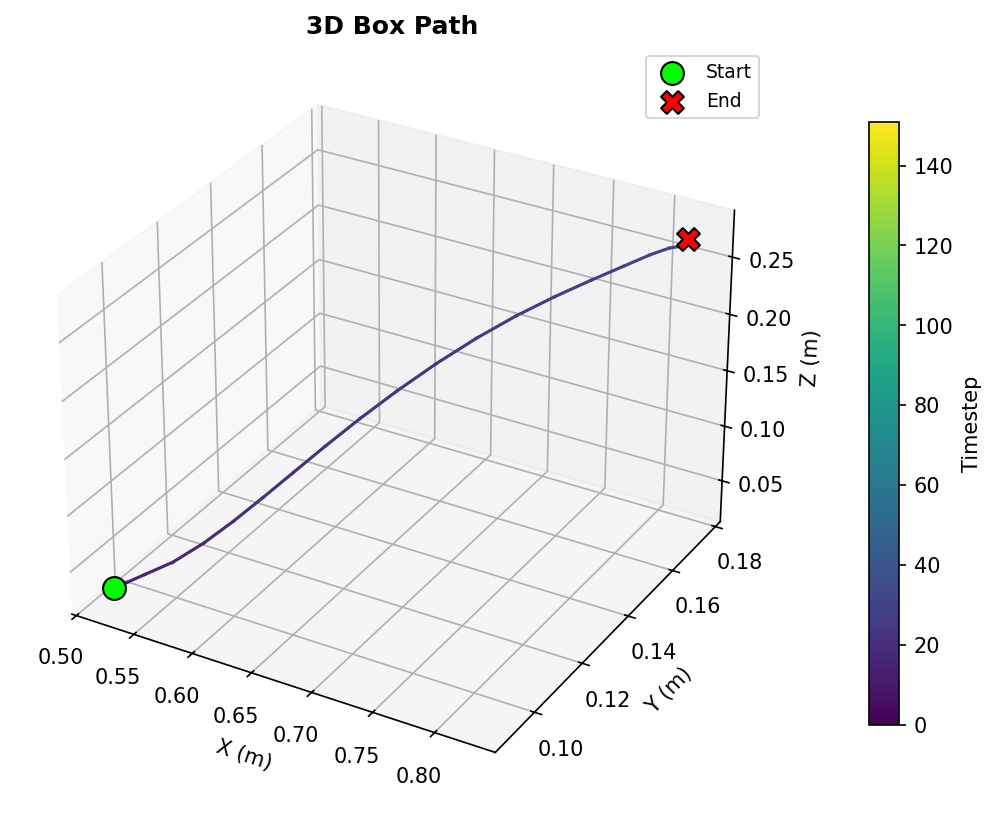

Saved: run_graphs/DomainR_off_forcerange10_20260206_173852_9143/DomainR_off_forcerange10_20260206_173852_9143_steps45875200.mp4
Saved: run_graphs/DomainR_off_forcerange10_20260206_173852_9143/DomainR_off_forcerange10_20260206_173852_9143_steps45875200_3d_path.png


In [8]:
import base64

# ── Generate 3D box path image ──
path_img_path = RUN_DIR
if box_pos_cols and len(box_pos_cols) >= 3:
    bx, by, bz = box_pos_cols[0], box_pos_cols[1], box_pos_cols[2]
    x = df[bx].values
    y = df[by].values
    z = df[bz].values

    fig = plt.figure(figsize=(7, 7))
    ax3 = fig.add_subplot(111, projection='3d')

    t_norm = np.linspace(0, 1, len(x))
    for i in range(len(x) - 1):
        ax3.plot(x[i:i+2], y[i:i+2], z[i:i+2],
                 color=plt.cm.viridis(t_norm[i]), lw=1.5)

    ax3.scatter(x[0], y[0], z[0], s=120, c='lime', marker='o',
                edgecolors='k', zorder=5, label='Start')
    ax3.scatter(x[-1], y[-1], z[-1], s=120, c='red', marker='X',
                edgecolors='k', zorder=5, label='End')

    ax3.set_xlabel('X (m)')
    ax3.set_ylabel('Y (m)')
    ax3.set_zlabel('Z (m)')
    ax3.set_title('3D Box Path', fontweight='bold')
    ax3.legend(fontsize=9)

    sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(0, len(x)))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax3, shrink=0.6, pad=0.1)
    cbar.set_label('Timestep')

    plt.tight_layout()
    plt.savefig('box_3d_path.png', dpi=150, bbox_inches='tight')
    plt.close()
    path_img_path = 'box_3d_path.png'

    dx, dy, dz = x[-1]-x[0], y[-1]-y[0], z[-1]-z[0]
    dist = np.sqrt(dx**2 + dy**2 + dz**2)
    print(f'Box: ({x[0]:.3f},{y[0]:.3f},{z[0]:.3f}) → ({x[-1]:.3f},{y[-1]:.3f},{z[-1]:.3f})  Δ={dist:.4f}m')

# ── Display side by side ──
with open(video_path, 'rb') as f:
    vid_b64 = base64.b64encode(f.read()).decode('utf-8')

if path_img_path:
    with open(path_img_path, 'rb') as f:
        img_b64 = base64.b64encode(f.read()).decode('utf-8')

    html = f'''
    <div style="display:flex; gap:20px; align-items:flex-start;">
        <div style="flex:1;">
            <h3>Rollout Video (steps {vf_steps:,})</h3>
            <video width="100%" controls autoplay loop muted>
                <source src="data:video/mp4;base64,{vid_b64}" type="video/mp4">
            </video>
        </div>
        <div style="flex:1;">
            <h3>3D Box Movement Path</h3>
            <img src="data:image/png;base64,{img_b64}" width="100%" />
        </div>
    </div>
    '''
    display(HTML(html))
    # ── Save with run_id in filename ──
    import shutil

    out_video = os.path.join(RUN_DIR, f'{RUN_ID}_steps{vf_steps}.mp4')
    out_3d    = os.path.join(RUN_DIR, f'{RUN_ID}_steps{vf_steps}_3d_path.png')

    shutil.copy(video_path, out_video)
    print(f'Saved: {out_video}')

    if path_img_path:
        shutil.copy(path_img_path, out_3d)
        print(f'Saved: {out_3d}')
else:
    display(HTML(f'''
    <video width="700" controls autoplay loop muted>
        <source src="data:video/mp4;base64,{vid_b64}" type="video/mp4">
    </video>
    '''))


## 6 — Manipulator Joint Angles [−π, +π]

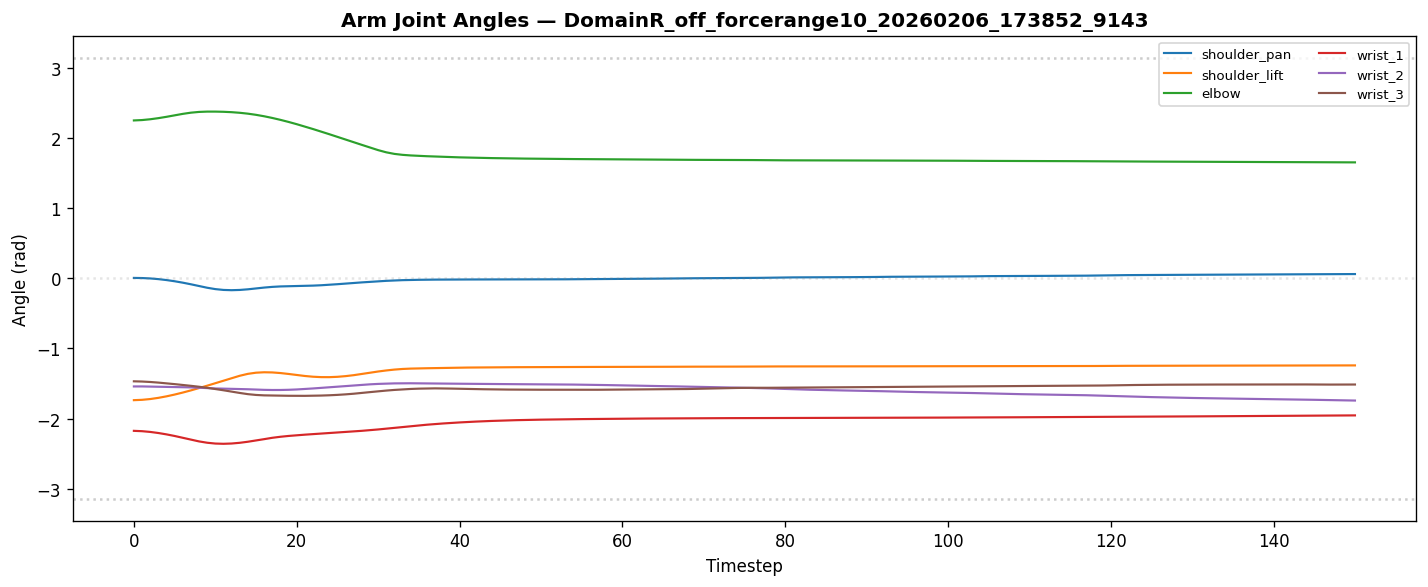

In [9]:
if arm_qpos_cols:
    t = df['timestep'].values
    fig, ax = plt.subplots(figsize=(12, 5))

    colors = plt.cm.tab10.colors
    for i, col in enumerate(arm_qpos_cols):
        angles = np.arctan2(np.sin(df[col].values), np.cos(df[col].values))
        ax.plot(t, angles, lw=1.3, color=colors[i % len(colors)],
                label=qpos_name_map[col])

    ax.set_ylim(-np.pi * 1.1, np.pi * 1.1)
    ax.axhline( np.pi, color='gray', ls=':', alpha=0.4)
    ax.axhline(-np.pi, color='gray', ls=':', alpha=0.4)
    ax.axhline(0,      color='gray', ls=':', alpha=0.2)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Angle (rad)')
    ax.set_title(f'Arm Joint Angles — {run.name}', fontweight='bold')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, 'arm_joint_angles.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('No qpos columns found.')


## 7 — Finger / Gripper Positions

So 4 N·m with a ~40–50mm finger gives roughly 80–100 N per finger, which is about 8–10 kg of grip force per finger. That's comfortably enough to hold a small cube.
You can check the exact lever arm in your MuJoCo XML — look for the finger joint's body position offset or the site where contact happens relative to the joint axis. Something like:

TypeError: join() got an unexpected keyword argument 'dpi'

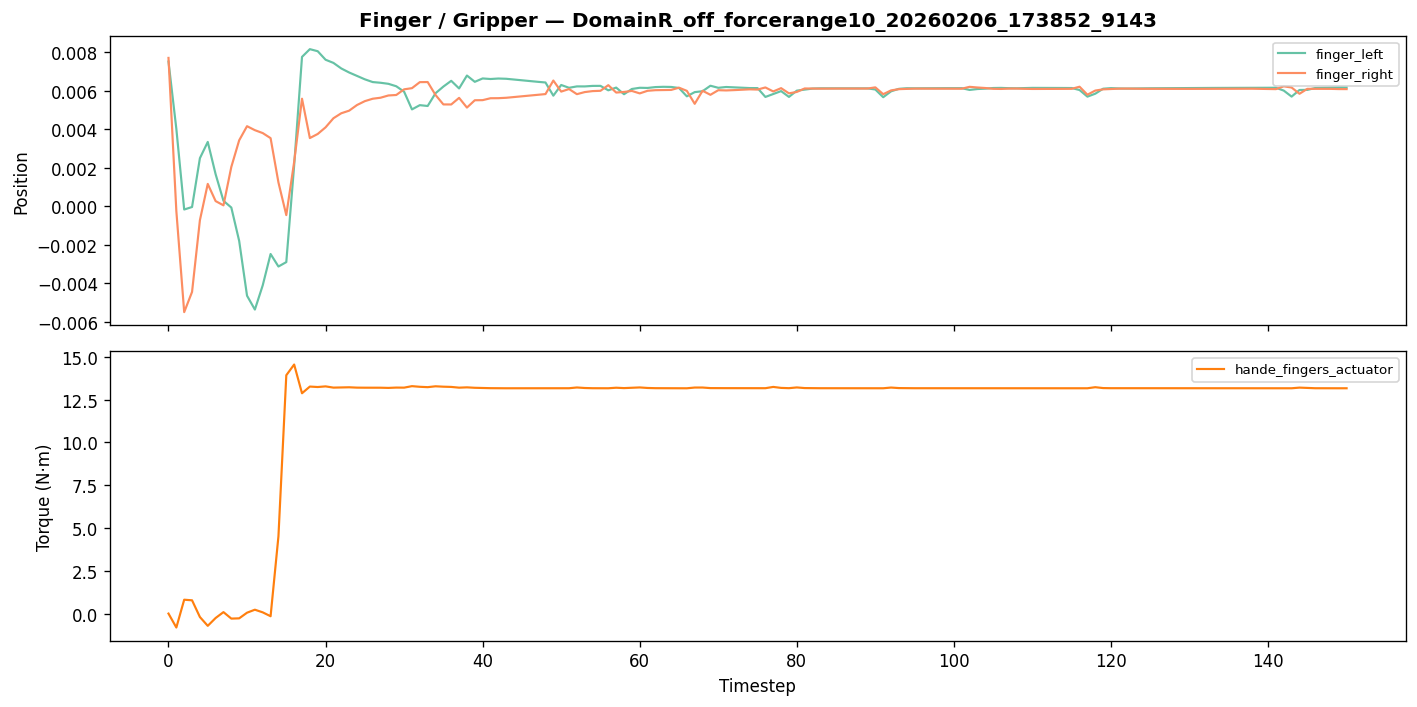

In [ ]:
if finger_qpos_cols:
    t = df['timestep'].values
    finger_torque = [c for c in torque_cols if 'finger' in c or 'hand' in c]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                                    gridspec_kw={'height_ratios': [1, 1]})

    # ── Top: finger positions ──
    colors = plt.cm.Set2.colors
    for i, col in enumerate(finger_qpos_cols):
        ax1.plot(t, df[col].values, lw=1.3, color=colors[i % len(colors)],
                 label=qpos_name_map[col])
    ax1.set_ylabel('Position')
    ax1.set_title(f'Finger / Gripper — {run.name}', fontweight='bold')
    ax1.legend(loc='upper right', fontsize=8)

    # ── Bottom: finger torque ──
    if finger_torque:
        for i, col in enumerate(finger_torque):
            ax2.plot(t, df[col].values, lw=1.3, color='tab:orange',
                     label=col.replace('torque_', ''))
        ax2.set_ylabel('Torque (N·m)')
        ax2.legend(loc='upper right', fontsize=8)
    else:
        ax2.text(0.5, 0.5, 'No finger torque column found',
                 ha='center', va='center', transform=ax2.transAxes)

    ax2.set_xlabel('Timestep')
    plt.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, 'finger_pos_and_torque.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('No finger qpos columns found.')


In [ ]:
# Finger symmetry check
diff = df[finger_qpos_cols[0]].values - df[finger_qpos_cols[1]].values
print(f'Max finger asymmetry: {np.abs(diff).max():.4f}')
print(f'Final asymmetry:      {np.abs(diff[-1]):.6f}')
print(f'Converged after step: {np.argmax(np.abs(diff) < 0.001)}')

## 8 — Box Position over Time (X, Y, Z)

In [ ]:
if box_pos_cols and len(box_pos_cols) >= 3:
    t = df['timestep'].values
    bx, by, bz = box_pos_cols[0], box_pos_cols[1], box_pos_cols[2]
    labels = ['box_x', 'box_y', 'box_z']

    fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
    for ax, col, lbl, c in zip(axes, [bx, by, bz], labels,
                                ['tab:red', 'tab:green', 'tab:blue']):
        ax.plot(t, df[col].values, lw=1.5, color=c)
        ax.set_ylabel(lbl)
        ax.axhline(df[col].iloc[0], color=c, ls=':', alpha=0.3)

    axes[-1].set_xlabel('Timestep')
    axes[0].set_title(f'Box Position over Time — {run.name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, 'box_position_xyz.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('No box position columns found.')


## 9 — All Velocities

In [ ]:
if vel_cols:
    t = df['timestep'].values
    fig, ax = plt.subplots(figsize=(12, 5))

    colors = plt.cm.tab20.colors
    for i, col in enumerate(vel_cols):
        ax.plot(t, df[col].values, lw=1.0, color=colors[i % len(colors)],
                label=vel_name_map.get(col, col), alpha=0.85)

    ax.axhline(0, color='gray', ls=':', alpha=0.3)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Velocity (rad/s or m/s)')
    ax.set_title(f'All Velocities — {run.name}', fontweight='bold')
    ax.legend(loc='upper right', fontsize=7, ncol=3)
    plt.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, 'all_velocities.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('No velocity columns found.')


## 10 — All Torques

In [ ]:
if torque_cols:
    t = df['timestep'].values
    fig, ax = plt.subplots(figsize=(12, 5))

    colors = plt.cm.tab20.colors
    for i, col in enumerate(torque_cols):
        ax.plot(t, df[col].values, lw=1.0, color=colors[i % len(colors)],
                label=torque_names[i] if i < len(torque_names) else col, alpha=0.85)

    ax.axhline(0, color='gray', ls=':', alpha=0.3)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Torque (N·m)')
    ax.set_title(f'All Torques — {run.name}', fontweight='bold')
    ax.legend(loc='upper right', fontsize=7, ncol=3)
    plt.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, 'all_torques.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('No torque columns found.')


## 11 — Summary Statistics

In [ ]:
data_groups = [
    ('Joint Angles (arm)',  arm_qpos_cols),
    ('Finger Positions',    finger_qpos_cols),
    ('Box Position',        box_pos_cols),
    ('Velocities',          vel_cols),
    ('Torques',             torque_cols),
]

for title, group_cols in data_groups:
    if group_cols:
        print(f'\n── {title} ──')
        summary = df[group_cols].describe().T
        summary.columns = [c.capitalize() for c in summary.columns]
        display(summary[['Mean', 'Std', 'Min', 'Max']])
